In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler


── Linear Regression ──
R² score: 0.4526
RMSE:     53.85


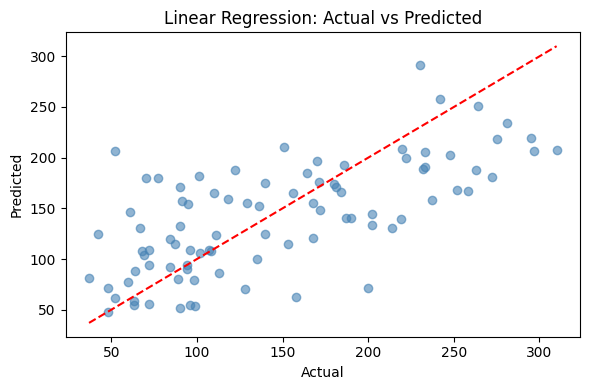

In [2]:
# ── 1. Linear Regression (predicting a number) ────
print("── Linear Regression ──")
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("R² score:", round(r2_score(y_test, y_pred), 4))
print("RMSE:    ", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

# Plot predictions vs actual
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()


── Logistic Regression ──
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



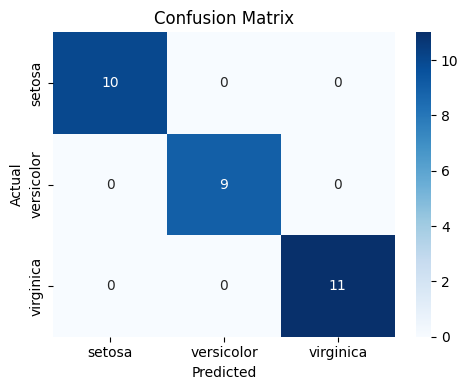

In [3]:
# ── 2. Logistic Regression (predicting a class) ───
print("\n── Logistic Regression ──")
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Always scale features for gradient-based models
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred,
      target_names=iris.target_names))

# Confusion matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [4]:
# ── 3. Decision Tree ──────────────────────────────
print("\n── Decision Tree ──")
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree Accuracy:", round(dt.score(X_test, y_test), 4))



── Decision Tree ──
Decision Tree Accuracy: 1.0



── Random Forest ──
Random Forest Accuracy: 1.0


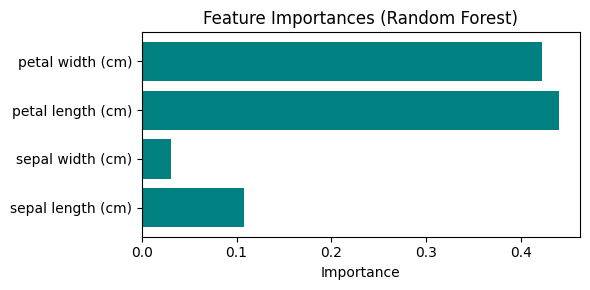


── Model Comparison ──
Logistic Regression      : 1.0
Decision Tree            : 1.0
Random Forest            : 1.0


In [5]:
# ── 4. Random Forest + Feature Importance ─────────
print("\n── Random Forest ──")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", round(rf.score(X_test, y_test), 4))

# Feature importance plot
importances = rf.feature_importances_
plt.figure(figsize=(6, 3))
plt.barh(iris.feature_names, importances, color='teal')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



In [6]:
# ── 5. Model comparison ───────────────────────────
models = {
    'Logistic Regression': log_reg,
    'Decision Tree':       dt,
    'Random Forest':       rf,
}
print("\n── Model Comparison ──")
for name, model in models.items():
    acc = round(model.score(X_test, y_test), 4)
    print(f"{name:25s}: {acc}")


── Model Comparison ──
Logistic Regression      : 1.0
Decision Tree            : 1.0
Random Forest            : 1.0
